In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Domestic Household Ice Cream Consumption

Ice cream includes regular, low-fat, and non-fat options. It does not include sherbet or other frozen dairy options.

In [2]:
# Selected soft dairy products, domestic use (Animal)
# Measured in millions of pounds

sdp_df = pd.read_excel('https://ers.usda.gov/media/5513/selected-soft-dairy-products-domestic-use-annual.xlsx?v=84869')

sdp_df

,"Selected soft dairy products, domestic use (millions of pounds)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Sum of Quantity,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Frozen products,NaN,NaN,NaN,NaN,NaN,NaN,"Soft products, others",NaN,NaN,Fluid cream,NaN,NaN,NaN,NaN
2,Year,"Ice cream, Regular","Ice cream, Low-fat","Ice cream, Non-fat",Frozen yogurt,Sherbet,Other frozen dairy¹,Water and juice ices,Yogurt other than frozen,Cottage cheese,Sour cream,Light cream,Heavy cream,Light cream + heavy cream,Half and half,Total fluid cream
3,1975,3931.8,1404.3,NaN,NaN,291.3,163,229.4,425,991,350,87,119,206,514,720
4,1976,3845.8,1345.1,NaN,NaN,297.5,137.9,228,465,1010,350,76,129,205,530,735
5,1977,3807.7,1447.9,NaN,NaN,298.7,134.9,223.6,515,1017,364,68,126,194,536,730
6,1978,3834.1,1458,NaN,NaN,288.2,132.7,203.8,545,1024,374,70,123,193,537,730
7,1979,3813.2,1394.7,NaN,NaN,270.7,125.6,192.5,550,998,395,66,139,205,543,748
8,1980,3898.1,1378.2,NaN,NaN,271.1,106.9,200.3,570,1004,408,55,159,214,551,765
9,1981,3908.6,1366.3,NaN,NaN,274.4,182.2,206.1,560,982,424,56,166,222,568,790


### Ice Cream Domestic Consumption Data Analysis and Preprocessing

The following is the code to clean the dataset so it only contains the year and domestic use of ice cream (regular, low-fat, and non-fat) for its corresponding year. The dataframes were graphed individually and together (all values displayed in one graph) using matplotlib.

In [3]:
sdp_df.columns.tolist()

['Selected soft dairy products, domestic use (millions of pounds)',
 'Unnamed: 1',
 'Unnamed: 2',
 'Unnamed: 3',
 'Unnamed: 4',
 'Unnamed: 5',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'Unnamed: 11',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15']

In [4]:
sdp_df.head()

,"Selected soft dairy products, domestic use (millions of pounds)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,Sum of Quantity,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Frozen products,NaN,NaN,NaN,NaN,NaN,NaN,"Soft products, others",NaN,NaN,Fluid cream,NaN,NaN,NaN,NaN
2,Year,"Ice cream, Regular","Ice cream, Low-fat","Ice cream, Non-fat",Frozen yogurt,Sherbet,Other frozen dairy¹,Water and juice ices,Yogurt other than frozen,Cottage cheese,Sour cream,Light cream,Heavy cream,Light cream + heavy cream,Half and half,Total fluid cream
3,1975,3931.8,1404.3,NaN,NaN,291.3,163,229.4,425,991,350,87,119,206,514,720
4,1976,3845.8,1345.1,NaN,NaN,297.5,137.9,228,465,1010,350,76,129,205,530,735


In [5]:
sdp_df.tail()

,"Selected soft dairy products, domestic use (millions of pounds)",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
52,2024,4084.958,1898.576,49.167,239.842,167.415,84.98,502.31,4931.249,806.246,1546.805,NaN,NaN,NaN,NaN,NaN
53,NA = Not available.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,¹Other frozen dairy products include mellorine...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,"Source: USDA, Economic Research Service calcul...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,"Last updated: August 28, 2025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
sdp_df.shape

(57, 16)

In [7]:
icecream_df = sdp_df.copy()

icecream_df = icecream_df[['Selected soft dairy products, domestic use (millions of pounds)',
                      'Unnamed: 1',
                      'Unnamed: 2',
                      'Unnamed: 3'
                      ]]

icecream_df

,"Selected soft dairy products, domestic use (millions of pounds)",Unnamed: 1,Unnamed: 2,Unnamed: 3
0,Sum of Quantity,,NaN,NaN
1,NaN,Frozen products,NaN,NaN
2,Year,"Ice cream, Regular","Ice cream, Low-fat","Ice cream, Non-fat"
3,1975,3931.8,1404.3,NaN
4,1976,3845.8,1345.1,NaN
5,1977,3807.7,1447.9,NaN
6,1978,3834.1,1458,NaN
7,1979,3813.2,1394.7,NaN
8,1980,3898.1,1378.2,NaN
9,1981,3908.6,1366.3,NaN


In [8]:
# Renaming the columns

icecream_df.rename(columns={'Selected soft dairy products, domestic use (millions of pounds)' : 'Year',
                         'Unnamed: 1': 'Ice Cream, Regular',
                         'Unnamed: 2': 'Ice Cream, Low-fat',
                         'Unnamed: 3': 'Ice Cream, Non-fat'
                         }, inplace=True)

icecream_df

,Year,"Ice Cream, Regular","Ice Cream, Low-fat","Ice Cream, Non-fat"
0,Sum of Quantity,,NaN,NaN
1,NaN,Frozen products,NaN,NaN
2,Year,"Ice cream, Regular","Ice cream, Low-fat","Ice cream, Non-fat"
3,1975,3931.8,1404.3,NaN
4,1976,3845.8,1345.1,NaN
5,1977,3807.7,1447.9,NaN
6,1978,3834.1,1458,NaN
7,1979,3813.2,1394.7,NaN
8,1980,3898.1,1378.2,NaN
9,1981,3908.6,1366.3,NaN


In [9]:
icecream_df = icecream_df.dropna()

In [10]:
icecream_df.shape

(31, 4)

In [11]:
icecream_df = icecream_df.drop(icecream_df.index[0:10]).reset_index(drop=True)

icecream_df


,Year,"Ice Cream, Regular","Ice Cream, Low-fat","Ice Cream, Non-fat"
0,2004,4290.7,1805.6,105.7
1,2005,4474.6,1679.1,97
2,2006,4578.2,1755.3,75.6
3,2007,4458.132,1780.91,67.041
4,2008,4338.868,1789.368,71.966
5,2009,4280.432,1863.076,78.179
6,2010,4321.653,1932.597,74.239
7,2011,4123.309,1928.331,79.642
8,2012,4138.691,2116.825,79.465
9,2013,4127.964,1844.297,65.436


-0.7173782011097746


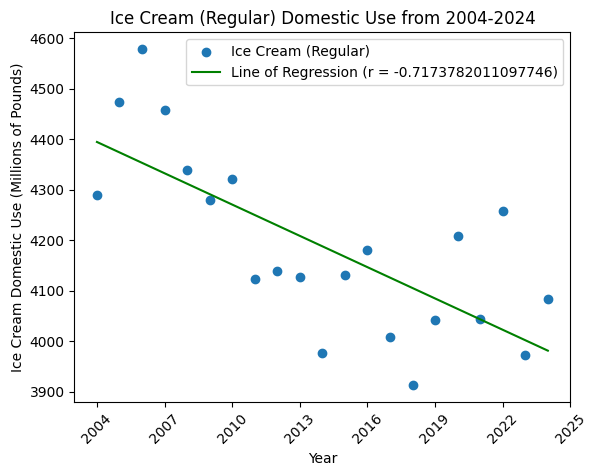

In [12]:
icecream_df['Year'] = pd.to_numeric(icecream_df['Year'], errors='coerce')

x = icecream_df['Year']
y = icecream_df['Ice Cream, Regular'].astype(int)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Graphing Ice Cream (Regular)
ax.scatter(x, y, label='Ice Cream (Regular)')

# Line of Best Fit
m, b = np.polyfit(x.astype(int), y, 1)
corr_matrix = x.corr(y)
plt.plot(x, m*x + b, color='green', label= f'Line of Regression (r = {corr_matrix})')
print(corr_matrix)

plt.xlabel('Year')
plt.ylabel('Ice Cream Domestic Use (Millions of Pounds)')
plt.title('Ice Cream (Regular) Domestic Use from 2004-2024')
plt.xticks(rotation=45)
plt.legend(loc = 'upper right',)
plt.show()

0.7533166922946918


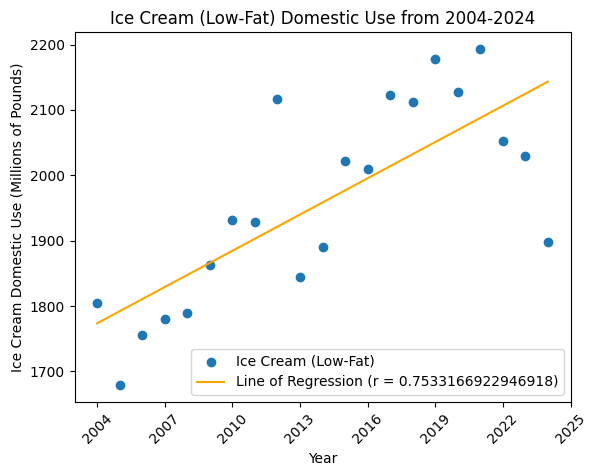

In [13]:
x_lf = icecream_df['Year']
y_lf = icecream_df['Ice Cream, Low-fat'].astype(int)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Graphing Ice Cream (Low-Fat)
ax.scatter(x_lf, y_lf, label='Ice Cream (Low-Fat)')

# Line of Best Fit
m, b = np.polyfit(x_lf.astype(int), y_lf, 1)
corr_matrix = x_lf.corr(y_lf)
plt.plot(x_lf, m*x + b, color='orange', label=f'Line of Regression (r = {corr_matrix})')
print(corr_matrix)


plt.xlabel('Year')
plt.ylabel('Ice Cream Domestic Use (Millions of Pounds)')
plt.title('Ice Cream (Low-Fat) Domestic Use from 2004-2024')
plt.xticks(rotation=45)
plt.legend()
plt.show()

-0.7345250749493959


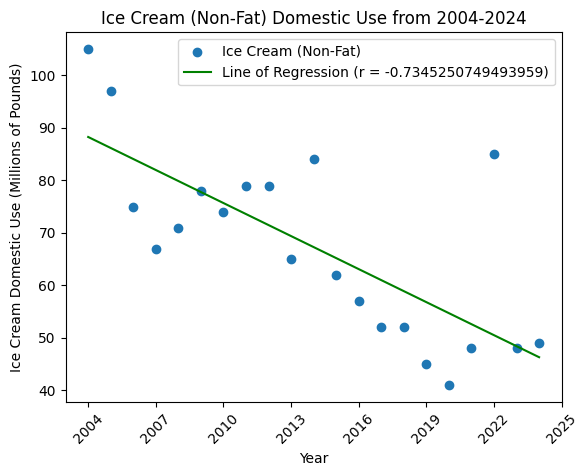

In [14]:
x_nf = icecream_df['Year']
y_nf = icecream_df['Ice Cream, Non-fat'].astype(int)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Graphing Ice Cream (Non-Fat)
ax.scatter(x_nf, y_nf, label='Ice Cream (Non-Fat)')

# Line of Best Fit
m, b = np.polyfit(x_nf.astype(int), y_nf, 1)
corr_matrix = x_nf.corr(y_nf)
plt.plot(x_nf, m*x + b, color='green', label=f'Line of Regression (r = {corr_matrix})')
print(corr_matrix)


plt.xlabel('Year')
plt.ylabel('Ice Cream Domestic Use (Millions of Pounds)')
plt.title('Ice Cream (Non-Fat) Domestic Use from 2004-2024')
plt.xticks(rotation=45)
plt.legend()
plt.show()

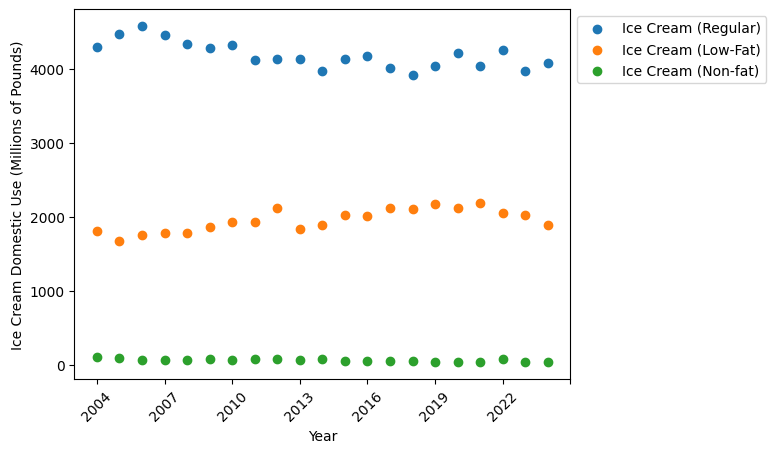

In [17]:
# Graphing All Three Ice Cream Types Together

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Ice Cream, Regular
plt.scatter(icecream_df['Year'].astype(str), icecream_df['Ice Cream, Regular'])

# Ice Cream, Low-fat
plt.scatter(icecream_df['Year'].astype(str), icecream_df['Ice Cream, Low-fat'])

# Ice Cream, Non-fat
plt.scatter(icecream_df['Year'].astype(str), icecream_df['Ice Cream, Non-fat'])

plt.xlabel('Year')
plt.ylabel('Ice Cream Domestic Use (Millions of Pounds)')
plt.title('')
plt.legend(['Ice Cream (Regular)', 'Ice Cream (Low-Fat)', 'Ice Cream (Non-fat)'], bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

All three ice cream types showed strong correlations (r > 0.7). Non-fat and regular ice cream exhibited downward trends over time, while low-fat ice cream showed an upward trend. This suggests differing consumer preferences across product types. The negative trends in non-fat and regular ice cream may reflect shifting dietary preferences, which could be influenced by increasing health consciousness and competition from alternative dairy desserts such as sorbet and frozen yoghurt.

## Median Household Income Data Analysis and Preprocessing

The dataset already adjusted the household income for inflation and encompasses the years 2004 to 2024. The following is the code to clean the dataset so it only contains the year and household income specifically for those with a bachelor's degree and higher. The dataframe was graphed using matplotlib.


In [18]:
# Median household income

household_income_df = pd.read_excel('https://www2.census.gov/programs-surveys/demo/tables/p60/286/inc_ed.xlsx')

household_income_df

,Table with row headers in column A and column headers in rows 4 through 5,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Median Household Income and Median Earnings by...,NaN,NaN,NaN,NaN,NaN,NaN
1,"(Income and earnings in 2024 dollars, adjusted...",NaN,NaN,NaN,NaN,NaN,NaN
2,Year,Median household income\n(dollars),NaN,NaN,NaN,"Median earnings of full-time, \nyear-round wor...",NaN
3,NaN,No high school diploma,"High school, \nno college",Some college,Bachelor's degree or higher,"High school, \nno college",Bachelor's degree or higher
4,2024,36900,58410,76520,132700,50640,91250
5,2023,37570,57250,75510,130100,50070,91720
6,2022,37150,54860,73230,126200,49720,89090
7,2021,34880,57870,73910,132600,50850,93360
8,2020 1,35670,57260,76860,128800,50890,92490
9,2019,37520,59030,78420,131700,50240,91080


In [19]:
bach_income_df = household_income_df.copy()

bach_income_df = bach_income_df[['Table with row headers in column A and column headers in rows 4 through 5', 'Unnamed: 4']]

bach_income_df

,Table with row headers in column A and column headers in rows 4 through 5,Unnamed: 4
0,Median Household Income and Median Earnings by...,NaN
1,"(Income and earnings in 2024 dollars, adjusted...",NaN
2,Year,NaN
3,NaN,Bachelor's degree or higher
4,2024,132700
5,2023,130100
6,2022,126200
7,2021,132600
8,2020 1,128800
9,2019,131700


In [20]:
bach_income_df = bach_income_df.rename(columns={'Table with row headers in column A and column headers in rows 4 through 5': 'Year',
                                                'Unnamed: 4': "Median Household Income (Dollars, Bachelor's Degree or Higher)"
                                               })

bach_income_df = bach_income_df.dropna()

bach_income_df

,Year,"Median Household Income (Dollars, Bachelor's Degree or Higher)"
4,2024,132700
5,2023,130100
6,2022,126200
7,2021,132600
8,2020 1,128800
9,2019,131700
10,2018,125200
11,2017 2,125800
12,2017,125500
13,2016,123900


In [21]:
bach_income_df['Year'] = bach_income_df['Year'].astype(str).str.extract(r'(\d{4})')

# Reverse the columns
bach_income_df['Year'] = bach_income_df['Year'].values[::-1]

bach_income_df["Median Household Income (Dollars, Bachelor's Degree or Higher)"] = bach_income_df["Median Household Income (Dollars, Bachelor's Degree or Higher)"].values[::-1]

bach_income_df

,Year,"Median Household Income (Dollars, Bachelor's Degree or Higher)"
4,2004,117300
5,2005,118400
6,2006,121800
7,2007,122800
8,2008,119300
9,2009,116400
10,2010,113900
11,2011,113100
12,2012,114200
13,2013,112800


In [22]:
bach_income_df = bach_income_df.drop(bach_income_df.index[9])

bach_income_df = bach_income_df.drop(bach_income_df.index[14])

bach_income_df

,Year,"Median Household Income (Dollars, Bachelor's Degree or Higher)"
4,2004,117300
5,2005,118400
6,2006,121800
7,2007,122800
8,2008,119300
9,2009,116400
10,2010,113900
11,2011,113100
12,2012,114200
14,2013,116800


0.7687195102319717


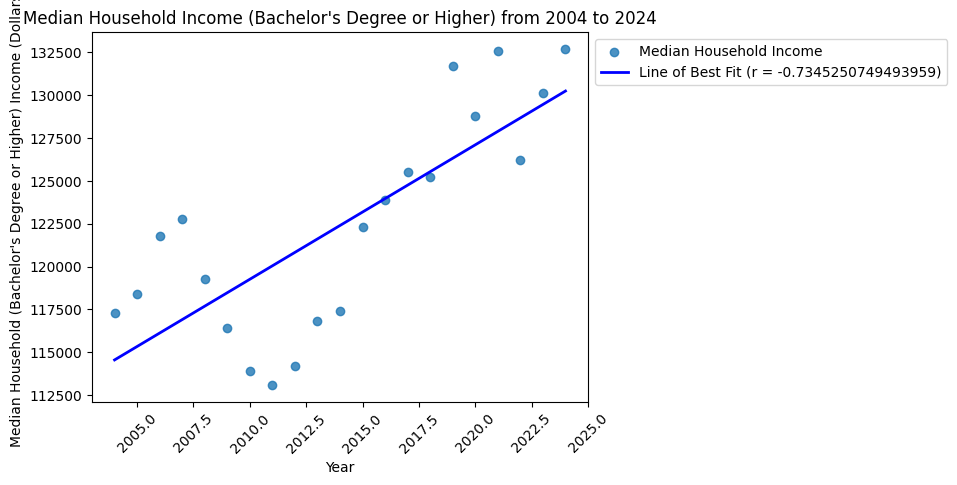

In [23]:
x_income = bach_income_df['Year'].astype(int)
y_income = bach_income_df["Median Household Income (Dollars, Bachelor's Degree or Higher)"].astype(int)

sns.regplot(x=x_income, y=y_income, data=bach_income_df, fit_reg=True, ci=None, label='Median Household Income', line_kws={"color": "blue", "lw": 2, "ls": "-", "label": f"Line of Best Fit (r = {corr_matrix})"})
corr_matrix = x_income.corr(y_income)
print(corr_matrix)

plt.xlabel('Year')
plt.ylabel("Median Household (Bachelor's Degree or Higher) Income (Dollars)")
plt.title("Median Household Income (Bachelor's Degree or Higher) from 2004 to 2024")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()


Median household income saw an upward trend between the years 2004 and 2024. The correlation coefficient (r = 0.36) suggests a positive weak linear relationship between year and median household income. Although income generally increased over time, fluctuations in data may be a result of major economic events such as the 2008 financial crisis and the COVID-19 pandemic.

## Analyzing the Relationship Between Ice Cream and Median Household Income

The following is the code to merge the two dataframes created for ice cream domestic consumption and median household income. The dataframes were then graphed using seaborn to visualize their relationship.

In [24]:
year = bach_income_df['Year']
x = bach_income_df["Median Household Income (Dollars, Bachelor's Degree or Higher)"]

y_regular = icecream_df['Ice Cream, Regular']
y_lowfat = icecream_df['Ice Cream, Low-fat']
y_nonfat = icecream_df['Ice Cream, Non-fat']

# Combine the four into a new dataframe (concat)

income_icecream_df = pd.concat([
    year.reset_index(drop=True),
    x.reset_index(drop=True),
    y_regular.reset_index(drop=True),
    y_lowfat.reset_index(drop=True),
    y_nonfat.reset_index(drop=True),
], axis=1)

income_icecream_df


,Year,"Median Household Income (Dollars, Bachelor's Degree or Higher)","Ice Cream, Regular","Ice Cream, Low-fat","Ice Cream, Non-fat"
0,2004,117300,4290.7,1805.6,105.7
1,2005,118400,4474.6,1679.1,97
2,2006,121800,4578.2,1755.3,75.6
3,2007,122800,4458.132,1780.91,67.041
4,2008,119300,4338.868,1789.368,71.966
5,2009,116400,4280.432,1863.076,78.179
6,2010,113900,4321.653,1932.597,74.239
7,2011,113100,4123.309,1928.331,79.642
8,2012,114200,4138.691,2116.825,79.465
9,2013,116800,4127.964,1844.297,65.436


-0.35532400574553297
0.5218976935528354
-0.7450889052323435


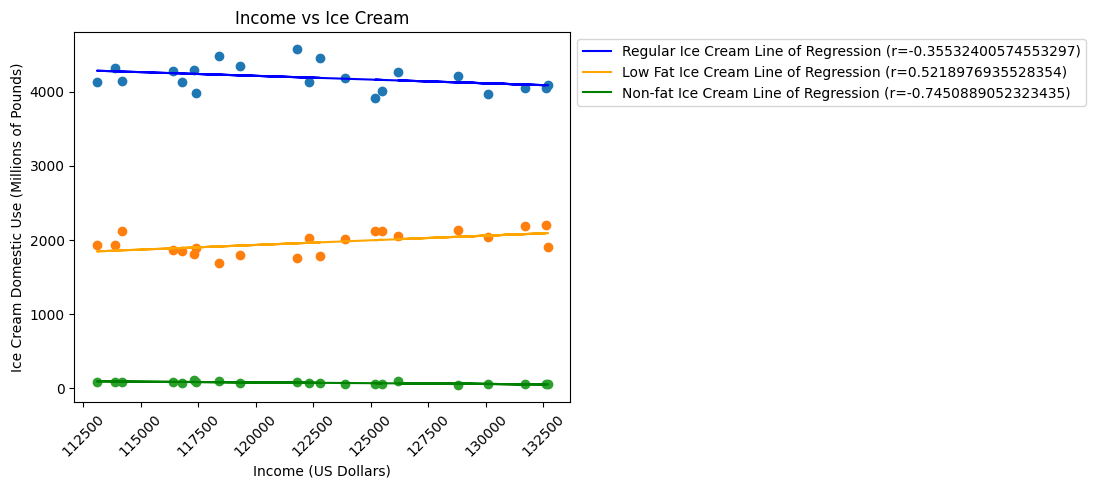

In [25]:
# Graphing New DataFrame

income_x = income_icecream_df["Median Household Income (Dollars, Bachelor's Degree or Higher)"].astype(int)
y_regular_icecream = income_icecream_df['Ice Cream, Regular'].astype(int)
y_lowfat_icecream = income_icecream_df['Ice Cream, Low-fat'].astype(int)
y_nonfat_icecream = income_icecream_df['Ice Cream, Non-fat'].astype(int)

plt.scatter(income_x, y_regular_icecream)
plt.scatter(income_x, y_lowfat_icecream)
plt.scatter(income_x, y_nonfat_icecream)

# Line of Best Fits
m1, b1 = np.polyfit(income_x.astype(int), y_regular_icecream, 1)
corr_matrix_regular = income_x.corr(y_regular_icecream)
plt.plot(income_x, m1*income_x + b1, color='blue', label=f'Regular Ice Cream Line of Regression (r={corr_matrix_regular})')
print(corr_matrix_regular)

m2, b2 = np.polyfit(income_x.astype(int), y_lowfat_icecream, 1)
corr_matrix_lowfat = income_x.corr(y_lowfat_icecream)
plt.plot(income_x, m2*income_x + b2, color='orange', label=f'Low Fat Ice Cream Line of Regression (r={corr_matrix_lowfat})')
print(corr_matrix_lowfat)

m3, b3 = np.polyfit(income_x.astype(int), y_nonfat_icecream, 1)
corr_matrix_nonfat = income_x.corr(y_nonfat_icecream)
plt.plot(income_x, m3*income_x + b3, color='green', label=f'Non-fat Ice Cream Line of Regression (r={corr_matrix_nonfat})')
print(corr_matrix_nonfat)


plt.xlabel('Income (US Dollars)')
plt.ylabel('Ice Cream Domestic Use (Millions of Pounds)')
plt.title('Income vs Ice Cream')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

Income is associated differently with each type, and exhibits the substitution pattern. People with higher income shift towards one preferred type and away from the others. Low-fat ice cream preference increases with income, while non-fat ice cream preference strongly decreases with income. Regular ice cream preference slightly decreases with income.